In [1]:
# -*- coding: utf-8 -*-
# Licensed under a 3-clause BSD style license - see LICENSE.rst
import logging
import os
import warnings
from collections import OrderedDict
from multiprocessing import Pool

import astropy
from astropy.table import Table, hstack
import astropy.units as u
from astropy.io import ascii
from astropy.constants import alpha, c, e, hbar, m_e, m_p, sigma_sb
from astropy.utils.data import get_pkg_data_filename

import numpy as np
import matplotlib.pyplot as plt

from Validator import (
    validate_array,
    validate_physical_type,
    validate_scalar,
)
#from .model_utils import memoize
from Utils import trapz_loglog

import Models
import RadiativeCopy
import NO_UNITS_Radiative as Radiative

from astropy.units import def_physical_type

try:
    #def_physical_type(u.Unit("1 / eV"), "differential energy")
    def_physical_type(u.erg / u.cm**2 / u.s, "flux")
    def_physical_type(u.Unit("1/(s cm2 erg)"), "differential flux")
    def_physical_type(u.Unit("1/(s erg)"), "differential power")
    def_physical_type(u.Unit("1/TeV"), "differential energy")
    def_physical_type(u.Unit("1/cm3"), "number density")
    def_physical_type(u.Unit("1/(eV cm3)"), "differential number density")

except ValueError:
    print("New quantities already defined")

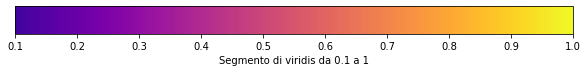

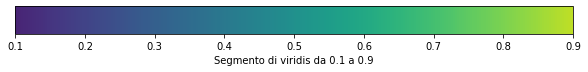

In [2]:

from matplotlib import cm
from matplotlib.colors import Normalize, LinearSegmentedColormap
from matplotlib.colorbar import ColorbarBase

def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    new_cmap = LinearSegmentedColormap.from_list(
        f'trunc({cmap.name},{minval:.2f},{maxval:.2f})',
        cmap(np.linspace(minval, maxval, n))
    )
    return new_cmap

vmin = 0.1
vmax = 1
original_cmap = plt.cm.plasma

cmap1 = truncate_colormap(original_cmap, vmin, vmax)
fig, ax = plt.subplots(figsize=(10, 1))
fig.subplots_adjust(bottom=0.5)
norm = Normalize(vmin, vmax)  # da 0 a 1 perché stai solo mostrando il segmento
cb = ColorbarBase(ax,cmap=cmap1,norm=norm,orientation='horizontal')
cb.set_label(f'Segmento di viridis da {vmin} a {vmax}')
plt.show()

vmin = 0.1
vmax = 0.9
original_cmap2 = plt.cm.viridis

cmap2 = truncate_colormap(original_cmap2, vmin, vmax)
fig, ax = plt.subplots(figsize=(10, 1))
fig.subplots_adjust(bottom=0.5)
norm = Normalize(vmin, vmax)  # da 0 a 1 perché stai solo mostrando il segmento
cb = ColorbarBase(ax,cmap=cmap2,norm=norm,orientation='horizontal')
cb.set_label(f'Segmento di viridis da {vmin} a {vmax}')
plt.show()


lunghezza_colori = 6

cmap1 = plt.cm.viridis  
colori1 = [cmap1(i) for i in np.linspace(0.3, 0.8, lunghezza_colori)]

cmap2= plt.cm.plasma
colori2 = [cmap2(i) for i in np.linspace(0.3, 0.8, lunghezza_colori)]

In [ ]:
# Definiamo i parametri del modello
#amplitude = 1e36* u.Unit('1/eV')
amplitude = 1.0 * u.Unit('1/eV')
e_0 = 1.0 * u.TeV  # Energia di riferimento
alpha_1 = 2.0
alpha_2= 3.5
e_cut=13*u.TeV
e_break= 2*u.TeV #3.0*u.TeV
beta=1

# Creiamo un'istanza della classe
PL= Models.PowerLaw(amplitude, e_0, alpha_1)
BPL=Models.BrokenPowerLaw(amplitude, e_0,e_break, alpha_1, alpha_2)

ECPL=Models.ExponentialCutoffPowerLaw(amplitude, e_0, alpha_1,e_cut)
ECBPL=Models.ExponentialCutoffBrokenPowerLaw(amplitude, e_0,e_break, alpha_1, alpha_2,e_cut)


In [ ]:
print(PL(1.0*u.TeV))

#energy_values = np.logspace(12,14,1000)*u.eV
#print(PL(energy_values))

print(type(PL))

In [ ]:
print(PL._calc(1.0*u.TeV))
print(BPL._calc(1.0*u.TeV))
print(ECPL._calc(1.0*u.TeV))
print(ECBPL._calc(1.0*u.TeV))

print(PL(1.0*u.TeV)) # using __call__
print(BPL(1.0*u.TeV)) # using __call__
print(ECPL(1.0*u.TeV)) # using __call__
print(ECBPL(1.0*u.TeV)) # using __call__



## Electron distributions

In [ ]:
#energy_values = np.logspace(0.2, 0.7, 100) * u.TeV  # Da 0.1 a 100 TeV
energy_values = np.logspace(12,14,1000)*u.eV

pd1=PL(energy_values)
pd2=BPL(energy_values)
pd3=ECPL(energy_values)
pd4=ECBPL(energy_values)

plt.figure(figsize=[12,7])
plt.plot(energy_values,pd1,color="green",label="PL")
plt.plot(energy_values,pd2,color="blue",label="BPL")
plt.plot(energy_values,pd3,color="red",label="ECPL")
plt.plot(energy_values,pd4,color="black",label="ECBPL")

plt.axvline(e_break.to(u.eV).value, color='darkgray', linestyle='--', label="break energy")
plt.axvline(e_cut.to(u.eV).value, color='black', linestyle='--', label="cutoff energy")
            
plt.xscale('log')
#plt.ylim(1e-2,1e0)
plt.yscale('log')
plt.legend()

plt.title( r'Distribution tests')
plt.xlabel('Energy [{0}]'.format(energy_values.unit.to_string('latex_inline')))
plt.ylabel('dN/dE')
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show



In [ ]:
plt.figure(figsize=[12,7])
plt.plot(energy_values,pd1,color="green",label="PL")
plt.plot(energy_values,pd2,color="blue",label="BPL")
plt.plot(energy_values,pd3,color="red",label="ECPL")
plt.plot(energy_values,pd4,color="black",label="ECBPL")

plt.axvline(e_break.to(u.eV).value, color='darkgray', linestyle='--', label="break energy")
plt.axvline(e_cut.to(u.eV).value, color='black', linestyle='--', label="cutoff energy")
            
#plt.xscale('log')
#plt.ylim(1e-2,1e0)
plt.yscale('log')
plt.legend()

plt.title( r'Distribution tests')
plt.xlabel('Energy [{0}]'.format(energy_values.unit.to_string('latex_inline')))
plt.ylabel('dN/dE')
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show

## Synchtron emission

In [ ]:

lunghezza_colori = 6

cmap1 = plt.cm.viridis  
colori1 = [cmap1(i) for i in np.linspace(0.3, 0.8, lunghezza_colori)]

cmap2= plt.cm.plasma
colori2 = [cmap2(i) for i in np.linspace(0.3, 0.8, lunghezza_colori)]

# Definiamo i parametri del modello
#amplitude = 1e36 *u.Unit('1/eV')
amplitude = 1. *u.Unit('1/eV')

e_0 = 1*u.TeV  # Energia di riferimento
alpha_1 = 2.1
alpha_2= 3.5

e_cut1=13*u.TeV
e_cut2=6*u.TeV

e_break=2.0*u.TeV
B_field=100*u.uG


PL = Models.PowerLaw(amplitude,e_0,alpha_1)
ECPL = Models.ExponentialCutoffPowerLaw(amplitude, e_0, alpha_1, e_cut1)
ECPL2= Models.ExponentialCutoffPowerLaw(amplitude, e_0, alpha_1, e_cut2)

SYN = RadiativeCopy.Synchrotron(PL, B=B_field)
SYN2= RadiativeCopy.Synchrotron(ECPL, B=B_field)
SYN3= RadiativeCopy.Synchrotron(ECPL2, B=B_field)

#Broken power
ECBPL1 = Models.ExponentialCutoffBrokenPowerLaw(amplitude, e_0, e_break,alpha_1,alpha_2,e_cutoff=e_cut1)
ECBPL2 = Models.ExponentialCutoffBrokenPowerLaw(amplitude, e_0, e_break,alpha_1,alpha_2,e_cutoff=e_cut2)


SYN4= RadiativeCopy.Synchrotron(ECBPL1, B=B_field)
SYN5= RadiativeCopy.Synchrotron(ECBPL2, B=B_field)

SYN4_No= Radiative.Synchrotron(ECBPL1, B=B_field)
SYN5_No= Radiative.Synchrotron(ECBPL2, B=B_field)

In [ ]:
print(SYN4.B)
print(SYN4_No.B)

In [ ]:
import time
# ---- Valore di riferimento ----
nEed_ref = 900
SYN4.nEed = nEed_ref
Etot_ref = SYN4.Etot
print(f"{Etot_ref:.4e}")

# ---- Lista di nEed da testare ----
nEed_values = np.linspace(1, 75, 100, dtype=int)
Etot_values = []
rel_errors = []


for n in nEed_values:
    SYN4.nEed = n
    E_tot = SYN4.Etot
    Etot_values.append(E_tot)
    
    # errore relativo rispetto al riferimento
    err_rel = abs(E_tot - Etot_ref) / Etot_ref
    rel_errors.append(err_rel)


# ==== Plot dell'integrale totale ----
plt.figure(figsize=(10,6))
plt.plot(nEed_values, Etot_values, 'o-', color='blue')
plt.axhline(Etot_ref, color='red', linestyle='--', label='Etot riferimento')
plt.xlabel("Numero di punti nEed")
plt.ylabel("Etot")
plt.title("Convergenza di Etot al variare di nEed")
plt.legend()
plt.grid(True, which='both', ls='--', alpha=0.7)
plt.show()

# ==== Plot dell'errore relativo ----
plt.figure(figsize=(10,6))
plt.plot(nEed_values, rel_errors, 'o-', color='green')
plt.xlabel("Numero di punti nEed")
plt.ylabel("Errore relativo")
plt.yscale('log')  # utile se errori molto piccoli
plt.title("Errore relativo di Etot rispetto al riferimento")
plt.grid(True, which='both', ls='--', alpha=0.7)
plt.show()



In [ ]:
# Compute SEDs
spectrum_energy = np.logspace(-1,14,1000)*u.eV
#spectrum_energy = np.asarray(1e6*u.eV)
dist=1.5*u.kpc

#spec_SYN=SYN._spectrum(spectrum_energy)
#spec_SYN2=SYN2._spectrum(spectrum_energy)
#spec_SYN3=SYN3._spectrum(spectrum_energy)

spec_SYN4=SYN4._spectrum(spectrum_energy)
spec_SYN5=SYN5._spectrum(spectrum_energy)

spec_SYN4N=SYN4_No._spectrum(spectrum_energy)
spec_SYN5N=SYN5_No._spectrum(spectrum_energy)



In [ ]:
plt.figure(figsize=(12,7))
#plt.rc('font', family='sans')
#plt.rc('mathtext', fontset='custom')



plt.loglog(spectrum_energy,np.squeeze(spec_SYN4),lw=2,label='Sync-ECBPL1',c=colori2[1])
plt.loglog(spectrum_energy,np.squeeze(spec_SYN5),lw=2,label='Sync-ECBPL2',c=colori2[2])

plt.loglog(spectrum_energy,np.squeeze(spec_SYN4N),lw=2,label='No',c=colori2[1])
plt.loglog(spectrum_energy,np.squeeze(spec_SYN5N),lw=2,label='No',c=colori2[2])

#plt.axvline(e_cut1.value, color='red', linestyle='--', label="Cutoff-1") 
#plt.axvline(e_cut2.value, color='darkred', linestyle='--', label="Cutoff-2") 

plt.xlabel('Photon energy [{0}]'.format(spectrum_energy.unit.to_string('latex_inline')),fontsize=15)

#plt.ylim(1e-52,1e-30)
#plt.xlim(1e-1, 1e10)
plt.tight_layout()
plt.legend(loc='lower left')
plt.legend(loc='lower left')


plt.title(f"Flux test for distance={dist}",fontsize=15)


plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.show

In [ ]:
spec_SYN=SYN._spectrum(spectrum_energy)
spec_SYN2=SYN2._spectrum(spectrum_energy)
spec_SYN3=SYN3._spectrum(spectrum_energy)

spec_SYN4=SYN4._spectrum(spectrum_energy)
spec_SYN5=SYN5._spectrum(spectrum_energy)

spec_SYN4N=SYN4_No._spectrum(spectrum_energy)
spec_SYN5N=SYN5_No._spectrum(spectrum_energy)

sed_SYN = SYN.sed(spectrum_energy, distance=1.5*u.kpc)
sed_SYN2 = SYN2.sed(spectrum_energy, distance=1.5*u.kpc)
sed_SYN3 = SYN3.sed(spectrum_energy, distance=1.5*u.kpc)

sed_SYN4 = SYN4.sed(spectrum_energy, distance=1.5*u.kpc)
sed_SYN5 = SYN5.sed(spectrum_energy, distance=1.5*u.kpc)


sed_SYN4N = SYN4_No.sed(spectrum_energy, distance=1.5*u.kpc)
sed_SYN5N = SYN5_No.sed(spectrum_energy, distance=1.5*u.kpc)

flux_SYN = SYN.flux(spectrum_energy, distance=dist)
flux_SYN2 = SYN2.flux(spectrum_energy, distance=dist)
flux_SYN3 = SYN3.flux(spectrum_energy, distance=dist)

flux_SYN4 = SYN4.flux(spectrum_energy, distance=dist)
flux_SYN5 = SYN5.flux(spectrum_energy, distance=dist)

flux_SYN4N = SYN4_No.flux(spectrum_energy, distance=dist)
flux_SYN5N = SYN5_No.flux(spectrum_energy, distance=dist)


sed_SYN=np.squeeze(sed_SYN)
sed_SYN2=np.squeeze(sed_SYN2)
sed_SYN3=np.squeeze(sed_SYN3)
sed_SYN4=np.squeeze(sed_SYN4)
sed_SYN5=np.squeeze(sed_SYN5)

flux_SYN=np.squeeze(flux_SYN)
flux_SYN2=np.squeeze(flux_SYN2)
flux_SYN3=np.squeeze(flux_SYN3)
flux_SYN4=np.squeeze(flux_SYN4)
flux_SYN5=np.squeeze(flux_SYN5)


flux_SYN4N=np.squeeze(flux_SYN4N)
flux_SYN5N=np.squeeze(flux_SYN5N)

### FLUX


In [ ]:

# Plot
plt.figure(figsize=(12,7))
#plt.rc('font', family='sans')
#plt.rc('mathtext', fontset='custom')

plt.loglog(spectrum_energy,flux_SYN,lw=2,label='Sync-PL',c="black")
plt.loglog(spectrum_energy,flux_SYN2,lw=2,label='Sync-ECPL',c=colori1[1])
plt.loglog(spectrum_energy,flux_SYN3,lw=2,label='Sync-ECPL2',c=colori1[2])

plt.loglog(spectrum_energy,flux_SYN4,lw=2,label='Sync-ECBPL1',c=colori2[1])
plt.loglog(spectrum_energy,flux_SYN5,lw=2,label='Sync-ECBPL2',c=colori2[2])

plt.loglog(spectrum_energy,flux_SYN4N,lw=2,label='No',c=colori2[1])
plt.loglog(spectrum_energy,flux_SYN5N,lw=2,label='No',c=colori2[2])

#plt.axvline(e_cut1.value, color='red', linestyle='--', label="Cutoff-1") 
#plt.axvline(e_cut2.value, color='darkred', linestyle='--', label="Cutoff-2") 

plt.xlabel('Photon energy [{0}]'.format(spectrum_energy.unit.to_string('latex_inline')),fontsize=15)
plt.ylabel('$Flux$ [{0}]'.format(flux_SYN.unit.to_string('latex_inline')),fontsize=15)
#plt.ylim(1e-52,1e-30)
#plt.xlim(1e-1, 1e10)
plt.tight_layout()
plt.legend(loc='lower left')
plt.legend(loc='lower left')


plt.title(f"Flux test for distance={dist}",fontsize=15)

plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.show

In [ ]:

dist=50*u.Mpc
flux_SYN = np.squeeze(SYN.flux(spectrum_energy, distance=dist))
flux_SYN2 = np.squeeze(SYN2.flux(spectrum_energy, distance=dist))
flux_SYN3 = np.squeeze(SYN3.flux(spectrum_energy, distance=dist))
flux_SYN4 = np.squeeze(SYN4.flux(spectrum_energy, distance=dist))
flux_SYN5 = np.squeeze(SYN5.flux(spectrum_energy, distance=dist))

plt.figure(figsize=(12,7))
#plt.rc('font', family='sans')
#plt.rc('mathtext', fontset='custom')

plt.loglog(spectrum_energy,flux_SYN,lw=2,label='Sync-PL',c="black")
plt.loglog(spectrum_energy,flux_SYN2,lw=2,label='Sync-ECPL',c=colori1[1])
plt.loglog(spectrum_energy,flux_SYN3,lw=2,label='Sync-ECPL2',c=colori1[2])

plt.loglog(spectrum_energy,flux_SYN4,lw=2,label='Sync-ECBPL1',c=colori2[1])
plt.loglog(spectrum_energy,flux_SYN5,lw=2,label='Sync-ECBPL2',c=colori2[2])


#plt.axvline(e_cut1.value, color='red', linestyle='--', label="Cutoff-1") 
#plt.axvline(e_cut2.value, color='darkred', linestyle='--', label="Cutoff-2") 

plt.xlabel('Photon energy [{0}]'.format(spectrum_energy.unit.to_string('latex_inline')),fontsize=15)
plt.ylabel('$Flux$ [{0}]'.format(flux_SYN.unit.to_string('latex_inline')),fontsize=15)
plt.ylim(1e-52,1e-30)
plt.xlim(1e-1, 1e10)
plt.tight_layout()
plt.legend(loc='lower left')
plt.legend(loc='lower left')

plt.title(f"Flux test for distance={dist}",fontsize=15)

plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.show

In [ ]:


# Plot
plt.figure(figsize=(12,7))
#plt.rc('font', family='sans')
#plt.rc('mathtext', fontset='custom')

plt.loglog(spectrum_energy,sed_SYN,lw=2,label='Sync-PL',c="black")
plt.loglog(spectrum_energy,sed_SYN2,lw=2,label='Sync-ECPL',c=colori1[1])
plt.loglog(spectrum_energy,sed_SYN3,lw=2,label='Sync-ECPL2',c=colori1[2])

plt.loglog(spectrum_energy,sed_SYN4,lw=2,label='Sync-ECBPL1',c=colori2[1])
plt.loglog(spectrum_energy,sed_SYN5,lw=2,label='Sync-ECBPL2',c=colori2[2])

plt.axvline(e_cut1.to(u.eV).value, color='red', linestyle='--', label="Cutoff-1") 
plt.axvline(e_cut2.to(u.eV).value, color='darkred', linestyle='--', label="Cutoff-2") 

plt.axvline(e_break.to(u.eV).value, color='darkgray', linestyle='--', label="break energy") 

plt.xlabel('Photon energy [{0}]'.format(spectrum_energy.unit.to_string('latex_inline')))
plt.ylabel('$E^2 dN/dE$ [{0}]'.format(sed_SYN.unit.to_string('latex_inline')))
plt.ylim(1e-52,1e-38)
plt.xlim(1e0, 1e10)
plt.tight_layout()
plt.legend(loc='lower left')
plt.legend(loc='lower left')


plt.title( r'SED tests')

plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.show

In [ ]:
# Plot
plt.figure(figsize=(12,7))
#plt.rc('font', family='sans')
#plt.rc('mathtext', fontset='custom')

plt.loglog(spectrum_energy,sed_SYN,lw=2,label='Sync-PL',c="black")
plt.loglog(spectrum_energy,sed_SYN2,lw=2,label='Sync-ECPL',c=colori1[1])
plt.loglog(spectrum_energy,sed_SYN3,lw=2,label='Sync-ECPL2',c=colori1[2])

plt.loglog(spectrum_energy,sed_SYN4,lw=2,label='Sync-ECBPL1',c=colori2[1])
plt.loglog(spectrum_energy,sed_SYN5,lw=2,label='Sync-ECBPL2',c=colori2[2])

plt.axvline(e_cut1.to(u.eV).value, color='red', linestyle='--', label="Cutoff-1") 
plt.axvline(e_cut2.to(u.eV).value, color='darkred', linestyle='--', label="Cutoff-2") 

plt.axvline(e_break.to(u.eV).value, color='darkgray', linestyle='--', label="break energy") 

plt.xlabel('Photon energy [{0}]'.format(spectrum_energy.unit.to_string('latex_inline')),fontsize=15)
plt.ylabel('$E^2 dN/dE$ [{0}]'.format(sed_SYN.unit.to_string('latex_inline')),fontsize=15)

plt.xlim(1e1, 1e14)
plt.ylim(1e-52,1e-38)

plt.tight_layout()
plt.legend(loc='lower left')
plt.legend(loc='lower left')


plt.title( r'SED tests',fontsize=15)

plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.show

In [ ]:

# Range di nEed da testare
nEed_values = np.linspace(10, 300, 40, dtype=int)

# Liste per salvare risultati
spectra_main = []     # spec
spectra_1 = []        # spec1
spectra_2 = []        # spec2
spectra_3 = []        # spec3

times_trapz = []
times_trapz_nd = []
times_trapz_fast = []
times_simps = []
E=[]

# Loop sui diversi valori di nEed
for n in nEed_values:
    SYN_test = RadiativeCopy.Synchrotron(ECBPL2, B=B_field, nEed=n)

    (spec, spec1, spec2, spec3,
     t_trapz, t_trapz_nd, t_trapz_fast, t_simps) = SYN_test._spectrum(spectrum_energy)
    
    E.append(SYN_test.Etot)

    # --- salva spettri ---
    spectra_main.append(np.squeeze(spec))
    spectra_1.append(np.squeeze(spec1))
    spectra_2.append(np.squeeze(spec2))
    spectra_3.append(np.squeeze(spec3))

    # --- salva tempi ---
    times_trapz.append(t_trapz)
    times_trapz_nd.append(t_trapz_nd)
    times_trapz_fast.append(t_trapz_fast)
    times_simps.append(t_simps)


# =============================
#   PLOT 1 — TEMPI DI INTEGRAZIONE
# =============================
plt.figure(figsize=(10,6))
plt.plot(nEed_values, times_trapz, "o-", label="trapz_loglog")
plt.plot(nEed_values, times_trapz_nd, "s-", label="trapz_loglog_nd")
plt.plot(nEed_values, times_trapz_fast, "^-", label="trapz_loglog_nd_fast")
plt.plot(nEed_values, times_simps, "d-", label="simps_loglog")

plt.xlabel("nEed")
plt.ylabel("Tempo di calcolo [s]")
plt.title("Tempi di integrazione vs nEed")
plt.yscale("log")
plt.grid(True, alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
plt.plot(nEed_values, E, 'o-', lw=1.5)
plt.xlabel("nEed")
plt.ylabel("Etot")
plt.title("Convergenza dell'energia Etot (scala log nEed)")
plt.grid(True, ls='--', alpha=0.6)
plt.tight_layout()
plt.show()

E_ref = E[-1]   # ultimo valore = più preciso

rel_err = np.abs((E - E_ref) / E_ref)

plt.figure(figsize=(10,6))
plt.plot(nEed_values, rel_err, 'o-')
plt.xlabel("nEed")
plt.ylabel("Errore relativo")
plt.title("Errore relativo di Etot rispetto al valore convergente")
plt.grid(True, which='both', ls='--', alpha=0.6)
plt.show()

## Inverse Compton emission

In [2]:
# Definiamo i parametri del modello
amplitude = 1e36 *u.Unit('1/eV')
e_0 = 1*u.TeV  # Energia di riferimento
alpha_1 = 2.1
alpha_2= 3.5

e_cut1=13*u.TeV
e_cut2=6*u.TeV

e_break=2.0*u.TeV
B_field=100*u.uG


#--------------------- A string equal to radiation fields: --------------------------------------------------------------------#
#                                                                                                                              #
#      "CMB" (default, Cosmic Microwave Background),2.72 K, energy densitiy of 0.261 eV/cm³                                    #
#      "NIR" (Near Infrared Radiation),  30 K, energy densitiy 0.5 eV/cm³                                                      #
#      "FIR" (Far Infrared Radiation), 3000 K,energy densitiy 1 eV/cm³                                                         #
#                                                                                                                              #
#      "mode NIR" ['NIR', 50 * u.K, 1.5 * u.eV / u.cm**3].                                                                     #
#      "hot, bright star at 120 degrees to the line-of-sight": ['star', 25000 * u.K, 3 * u.erg / u.cm**3, 120 * u.deg].        #
#      "emitter with spectral index 2 between 1 and 10 keV": ['X-ray', [1, 10] * u.keV, [1, 1e-2] * 1 / (u.eV * u.cm**3)].     #
#      "monochromatic photon field at 50 eV": ['UV', 50 * u.eV, 15 * u.eV / u.cm**3].                                          #
#                                                                                                                              #
#------------------------------------------------------------------------------------------------------------------------------#

PL = Models.PowerLaw(amplitude,e_0,alpha_1)
ECPL = Models.ExponentialCutoffPowerLaw(amplitude, e_0, alpha_1, e_cut1)
ECPL2= Models.ExponentialCutoffPowerLaw(amplitude, e_0, alpha_1, e_cut2)


#Broken power
ECBPL1 = Models.ExponentialCutoffBrokenPowerLaw(amplitude, e_0, e_break,alpha_1,alpha_2,e_cutoff=e_cut1)
ECBPL2 = Models.ExponentialCutoffBrokenPowerLaw(amplitude, e_0, e_break,alpha_1,alpha_2,e_cutoff=e_cut2)




# SSC- easy sphere

In [3]:
from astropy.constants import c
c_in_cm_per_s = c.to(u.cm / u.s)

SYN = RadiativeCopy.Synchrotron(ECBPL2,B=100*u.uG,nEed=20)
SYN_N = Radiative.Synchrotron(ECBPL2,B=100*u.uG,nEed=20)

# Define energy array for synchrotron seed photon field and compute
# Synchroton luminosity by setting distance to 0.
Esy = np.logspace(-6, 6, 40)*u.eV
sy = SYN._spectrum(Esy)
print(sy)

sy_N = SYN_N._spectrum(Esy)
print(sy_N)

#print(SYN.B.to("G").value)
#print(SYN_N.B)



[[3.23211539e+57 1.79982121e+57 9.29328417e+56 4.26345918e+56
  1.67858412e+56 5.83630784e+55 1.95044868e+55 6.50087760e+54
  2.16621805e+54 7.21582974e+53 2.40249858e+53 7.99366879e+52
  2.65712946e+52 8.82041939e+51 2.92233150e+51 9.65568270e+50
  3.17795515e+50 1.04015301e+50 3.37724738e+49 1.08377223e+49
  3.41772883e+48 1.04953545e+48 3.09194006e+47 8.52752171e+46
  2.12067915e+46 4.54457274e+45 8.22594172e+44 1.30716656e+44
  1.88131962e+43 2.40858639e+42 2.64940407e+41 2.39587392e+40
  1.68489230e+39 8.59161213e+37 2.90851170e+36 5.84872491e+34
  6.07157024e+32 2.72481930e+30 4.22237542e+27 1.70023030e+24]] 1 / (eV s)
[[3.23211539e+57 1.79982121e+57 9.29328417e+56 4.26345918e+56
  1.67858412e+56 5.83630784e+55 1.95044868e+55 6.50087760e+54
  2.16621805e+54 7.21582974e+53 2.40249858e+53 7.99366879e+52
  2.65712946e+52 8.82041939e+51 2.92233150e+51 9.65568270e+50
  3.17795515e+50 1.04015301e+50 3.37724739e+49 1.08377224e+49
  3.41772886e+48 1.04953547e+48 3.09194015e+47 8.52752212

  Name   = Speed of light in vacuum
  Value  = 299792458.0
  Uncertainty  = 0.0
  Unit  = m / s
  Reference = CODATA 2014


In [4]:
Esy = np.logspace(-6, 6, 40)*u.eV
Lsy = SYN.flux(Esy, distance=0*u.cm,)
print(Lsy)

Lsy_N = SYN_N.flux(Esy, distance=0*u.cm)
print(Lsy_N)

[[3.23211539e+57 1.79982121e+57 9.29328417e+56 4.26345918e+56
  1.67858412e+56 5.83630784e+55 1.95044868e+55 6.50087760e+54
  2.16621805e+54 7.21582974e+53 2.40249858e+53 7.99366879e+52
  2.65712946e+52 8.82041939e+51 2.92233150e+51 9.65568270e+50
  3.17795515e+50 1.04015301e+50 3.37724738e+49 1.08377223e+49
  3.41772883e+48 1.04953545e+48 3.09194006e+47 8.52752171e+46
  2.12067915e+46 4.54457274e+45 8.22594172e+44 1.30716656e+44
  1.88131962e+43 2.40858639e+42 2.64940407e+41 2.39587392e+40
  1.68489230e+39 8.59161213e+37 2.90851170e+36 5.84872491e+34
  6.07157024e+32 2.72481930e+30 4.22237542e+27 1.70023030e+24]] 1 / (eV s)
[[3.23211539e+57 1.79982121e+57 9.29328417e+56 4.26345918e+56
  1.67858412e+56 5.83630784e+55 1.95044868e+55 6.50087760e+54
  2.16621805e+54 7.21582974e+53 2.40249858e+53 7.99366879e+52
  2.65712946e+52 8.82041939e+51 2.92233150e+51 9.65568270e+50
  3.17795515e+50 1.04015301e+50 3.37724739e+49 1.08377224e+49
  3.41772886e+48 1.04953547e+48 3.09194015e+47 8.52752212

In [5]:
R = 2 * u.pc
phn_sy = Lsy / (4 * np.pi * R**2 * c) * 2.26
print(phn_sy.unit)

phn_sy_N = Lsy_N / (4 * np.pi * R**2 * c) * 2.26
print(phn_sy_N.unit)

1 / (eV m pc2)
s / (m pc2)


In [6]:
sed = SYN.sed(Esy, distance=4*u.kpc)
print(sed)

sed_N = SYN_N.sed(Esy, distance=4*u.kpc)
print(sed_N)

[[2.70499402e-12 6.21288669e-12 1.32317687e-11 2.50377563e-11
  4.06594054e-11 5.83096885e-11 8.03751273e-11 1.10495286e-10
  1.51865298e-10 2.08654266e-10 2.86542303e-10 3.93238809e-10
  5.39147447e-10 7.38190902e-10 1.00877323e-09 1.37477514e-09
  1.86629831e-09 2.51950453e-09 3.37415791e-09 4.46606630e-09
  5.80910682e-09 7.35789334e-09 8.94071102e-09 1.01706437e-08
  1.04324230e-08 9.22120967e-09 6.88438392e-09 4.51226917e-09
  2.67862099e-09 1.41447582e-09 6.41750348e-10 2.39368220e-10
  6.94319387e-11 1.46031459e-11 2.03904679e-12 1.69122810e-13
  7.24146825e-15 1.34044170e-16 8.56745204e-19 1.42294202e-21]] erg / (cm2 s)
[[2.70499402e-12 6.21288669e-12 1.32317687e-11 2.50377563e-11
  4.06594054e-11 5.83096885e-11 8.03751273e-11 1.10495286e-10
  1.51865298e-10 2.08654266e-10 2.86542303e-10 3.93238809e-10
  5.39147447e-10 7.38190902e-10 1.00877323e-09 1.37477514e-09
  1.86629831e-09 2.51950453e-09 3.37415791e-09 4.46606632e-09
  5.80910687e-09 7.35789346e-09 8.94071128e-09 1.01706

In [7]:
IC = RadiativeCopy.InverseCompton(ECBPL2, seed_photon_fields=[['SSC', Esy, phn_sy]])
IC_N = Radiative.InverseCompton(ECBPL2, seed_photon_fields=[['SSC', Esy, phn_sy_N]])

In [ ]:
#print(IC.seed_photon_fields['SSC'])
#print(IC.seed_photon_fields['SSC']["energy"])
#print(IC_N.seed_photon_fields['SSC']["energy"])
print("")
print(IC.seed_photon_fields['SSC']["photon_density"].value)
print(IC_N.seed_photon_fields['SSC']["photon_density"].value)

In [8]:
Lsy = IC._spectrum(Esy)
print(Lsy)

Lsy_N = IC_N._spectrum(Esy)
print(Lsy_N)

[3.00823512e+38 9.74964470e+38 1.14897935e+39 1.30842055e+39
 1.33980148e+39 1.36161452e+39 1.36523782e+39 1.36762371e+39
 1.36794277e+39 1.36804971e+39 1.36778755e+39 1.36724203e+39
 1.36617639e+39 1.36420435e+39 1.36059713e+39 1.35409026e+39
 1.34253727e+39 1.32244057e+39 1.28842146e+39 1.23296187e+39
 1.14730485e+39 1.02522059e+39 8.70634848e+38 6.96764662e+38
 4.91506388e+38 2.73054129e+38 1.41764300e+38 6.39506851e+37
 2.79074937e+37 1.12484622e+37 4.48487734e+36 1.71095087e+36
 6.51839461e+35 2.41164744e+35 8.93832125e+34 3.24188016e+34
 1.17898978e+34 4.21423020e+33 1.51035407e+33 5.33335355e+32] 1 / (eV s)
(1, 1, 40)
(1, 1, 40)
(40, 570, 40)
[3.01369277e+38 9.75103707e+38 1.14898187e+39 1.30842398e+39
 1.33980444e+39 1.36161755e+39 1.36524086e+39 1.36762676e+39
 1.36794584e+39 1.36805280e+39 1.36779068e+39 1.36724524e+39
 1.36617973e+39 1.36420794e+39 1.36060115e+39 1.35409502e+39
 1.34254327e+39 1.32244855e+39 1.28843241e+39 1.23297684e+39
 1.14732418e+39 1.02524225e+39 8.7065

In [12]:
E2 = np.tile(Esy, (5, 1))  
Lsy = IC._spectrum(E2)
print(Lsy)

Lsy_N = IC_N._spectrum(E2)
print(Lsy_N)

ValueError: operands could not be broadcast together with shapes (5,40) (200,) 

In [ ]:
# Plot
plt.figure(figsize=(12,7))
plt.rc('font', family='sans')
plt.rc('mathtext', fontset='custom')

spectrum_energy = np.logspace(-1,14,100)*u.eV
sed_IC=IC.sed(spectrum_energy, distance=1.5*u.kpc)
sed_IC2=IC_N.sed(spectrum_energy, distance=1.5*u.kpc)

#plt.loglog(spectrum_energy,sed_IC,lw=2,label='IC (total)',c=colori1[0])

plt.loglog(spectrum_energy,sed_IC2,lw=2,label='IC (total)',c="black")


plt.xlabel('Photon energy [{0}]'.format(
        spectrum_energy.unit.to_string('latex_inline')))
#plt.ylabel('$E^2 dN/dE$ [{0}]'.format(sed_SYN.unit.to_string('latex_inline')))
plt.ylim(1e-12, 1e-6)
plt.tight_layout()
plt.legend(loc='lower left')
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.show

In [ ]:

import Radiative
import RadiativeCopy


ECPL = Models.ExponentialCutoffPowerLaw(1e36*u.Unit('1/eV'), 1*u.TeV, 2.1, 13*u.TeV)
SYN = Radiative.Synchrotron(ECPL, B=100*u.uG)
SYN2 = RadiativeCopy.Synchrotron(ECPL, B=100*u.uG)

Esy = np.logspace(-6, 6, 100)*u.eV
Lsy = SYN.flux(Esy, distance=0*u.cm)

Lsy2 = SYN2.flux(Esy, distance=0*u.cm)

print(np.allclose(Lsy.value, Lsy2.value))

# Define source radius and compute photon density
R = 2 * u.pc
phn_sy = Lsy / (4 * np.pi * R**2 * c) * 2.26
phn_sy2 = Lsy2 / (4 * np.pi * R**2 * c) * 2.26

# Create IC instance with CMB and synchrotron seed photon fields:
IC = Radiative.InverseCompton(ECPL, seed_photon_fields=[['SSC', Esy, phn_sy]])
IC2 = RadiativeCopy.InverseCompton(ECPL, seed_photon_fields=[['SSC', Esy, phn_sy2]])

#print(IC._spectrum(Esy))
#print(IC2._spectrum(Esy))

# Compute SEDs
spectrum_energy = np.logspace(-1,14,100)*u.eV
sed_IC = IC.sed(spectrum_energy, distance=1.5*u.kpc)
sed_SYN = SYN.sed(spectrum_energy, distance=1.5*u.kpc)

sed_IC2 = IC2.sed(spectrum_energy, distance=1.5*u.kpc)
sed_SYN2 = SYN2.sed(spectrum_energy, distance=1.5*u.kpc)





In [ ]:
# Plot
plt.figure(figsize=(12,7))
plt.rc('font', family='sans')
plt.rc('mathtext', fontset='custom')

plt.loglog(spectrum_energy,np.squeeze(sed_SYN),lw=2,label='Sync',c=colori1[1])
plt.loglog(spectrum_energy,np.squeeze(sed_SYN2),lw=2,label='Sync',c="black")

plt.loglog(spectrum_energy,sed_IC,lw=2,label='IC (total)',c=colori1[0])

plt.loglog(spectrum_energy,sed_IC2,lw=2,label='IC (total)',c="black")


plt.xlabel('Photon energy [{0}]'.format(
        spectrum_energy.unit.to_string('latex_inline')))
plt.ylabel('$E^2 dN/dE$ [{0}]'.format(
        sed_SYN.unit.to_string('latex_inline')))
plt.ylim(1e-12, 1e-6)
plt.tight_layout()
plt.legend(loc='lower left')
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.show


In [15]:
import numpy as np
from numba import njit, prange, guvectorize, float64
import time

# ==========================
# Versione originale njit
# ==========================
@njit(cache=True)
def Fic_element(E1, gamma, E0):
    Gamma = 4 * gamma * E0
    w = E1 / gamma
    den = Gamma * (1-w)
    if den <= 0:
        return 0.0
    q = w / den
    if 1.0/(4*gamma**2) < q < 1.0:
        return 2*q*np.log(q) + (1 + 2*q)*(1 - q) + 0.5*(Gamma*q)**2*(1 - q)/(1 + Gamma*q)
    else:
        return 0.0

@njit(parallel=True, fastmath=True)
def compute_fic_numba_old(E1, gamma, E0):
    NE1 = E1.size
    Ngamma = gamma.size
    NE0 = E0.size
    fic = np.zeros((NE1, Ngamma, NE0), dtype=np.float64)
    for i in prange(NE1):
        E_1 = E1[i]
        for k in range(Ngamma):
            g = gamma[k]
            for l in range(NE0):
                E_0 = E0[l]
                fic[i,k,l] = Fic_element(E_1, g, E_0)
    return fic

# ==========================
# Versione vectorizzata guvectorize
# ==========================
@guvectorize(
    [(float64, float64, float64, float64[:])],
    '(),(),()->()', target='parallel', fastmath=True
)
def Fic_element_vec(E1, gamma, E0, out):
    Gamma = 4.0 * gamma * E0
    w = E1 / gamma
    den = Gamma * (1.0 - w)
    if den <= 0.0:
        out[0] = 0.0
    else:
        q = w / den
        if (1.0/(4*gamma**2)) < q < 1.0:
            out[0] = 2.0*q*np.log(q) + (1.0 + 2.0*q)*(1.0 - q) + 0.5*(Gamma*q)**2*(1 - q)/(1 + Gamma*q)
        else:
            out[0] = 0.0

def compute_fic_numba_new(E1, gamma, E0):
    E1 = np.asarray(E1, dtype=np.float64)
    gamma = np.asarray(gamma, dtype=np.float64)
    E0 = np.asarray(E0, dtype=np.float64)
    E1_grid, gamma_grid, E0_grid = np.meshgrid(E1, gamma, E0, indexing='ij')
    fic = Fic_element_vec(E1_grid, gamma_grid, E0_grid)
    return fic



# ==========================
# Parametri di test
# ==========================
E1 = np.linspace(1e-3, 1.0, 200)    # photon energy after scattering
gamma = np.linspace(10, 1000, 400)  # lorentz factor
E0 = np.linspace(1e-5, 1e-2, 200)    # photon energy before scattering

# ==========================
# Benchmark versione vecchia
# ==========================
start = time.time()
fic_old = compute_fic_numba_old(E1, gamma, E0)
t_old = time.time() - start
print(f"Vecchia versione njit: {t_old:.3f} s")

# ==========================
# Benchmark versione nuova
# ==========================
start = time.time()
fic_new = compute_fic_numba_new(E1, gamma, E0)
t_new = time.time() - start
print(f"Nuova versione vectorizzata: {t_new:.3f} s")




Vecchia versione njit: 1.259 s
Nuova versione vectorizzata: 0.253 s
